# Gym Insights

In [30]:
!pip install pandas openpyxl matplotlib seaborn


[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [31]:
import pandas as pd

def clean_gym_data(df):
    clean_weights = []
    latest_bw = 70.0  # Default fallback if BW isn't logged yet

    for _, row in df.iterrows():
        val = row["Weight"]

        if pd.isna(val):
            clean_weights.append(None)
            continue

        val_str = str(val).strip().lower()

        # 1. If row explicitly logs pure Bodyweight (e.g. 'bw')
        if val_str == "bw":
            # Check if BW column has the current weight, otherwise use latest_bw
            bw_to_use = row["BW"] if pd.notna(row["BW"]) else latest_bw
            clean_weights.append(float(bw_to_use))
            continue

        # Update latest_bw if a valid BW number exists in this row's BW column
        if pd.notna(row["BW"]):
            try:
                latest_bw = float(row["BW"])
            except ValueError:
                pass

        # 2. Weighted bodyweight (e.g., 'bw+10' or 'bw+5e')
        base_bw = 0.0
        if "bw" in val_str:
            base_bw = latest_bw
            val_str = val_str.replace("bw", "").replace("+", "").strip()

        # 3. Handle 'e' (each side)
        is_each = "e" in val_str
        val_str = val_str.replace("e", "").strip()

        # 4. Handle plate notation ('100/4')
        if "/" in val_str:
            val_str = val_str.split("/")[0].strip()

        try:
            weight = float(val_str)
            added_weight = weight * 2.0 if is_each else weight
            clean_weights.append(base_bw + added_weight)
        except ValueError:
            clean_weights.append(base_bw if base_bw > 0 else None)

    df["Clean_Weight"] = clean_weights
    return df

In [32]:
import pandas as pd

# 1. Read the Excel file
file_path = "workouts.xlsx"
df = pd.read_excel(file_path)

# 2. Inspect the first few rows and column data types
print(df.head())
print(df.info())

                          Exercise Weight  Set_1  Set_2  Set_3  Week   BW
0     Seated Hip Abduction Machine     50     12     12     12     1  100
1  Dumbbell Bulgarian Split Squats     BW      8     10     10     1  100
2                   Leg Extensions     50     12     12     12     1  100
3                  Lying Leg Curls     50     12     12      8     1  100
4             Standing Calf Raises     30     15     15     15     1  100
<class 'pandas.DataFrame'>
RangeIndex: 216 entries, 0 to 215
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Exercise  216 non-null    str   
 1   Weight    216 non-null    object
 2   Set_1     216 non-null    int64 
 3   Set_2     216 non-null    int64 
 4   Set_3     216 non-null    int64 
 5   Week      216 non-null    int64 
 6   BW        216 non-null    int64 
dtypes: int64(5), object(1), str(1)
memory usage: 11.9+ KB
None


In [35]:
# 2. Clean the Weight column
df = clean_gym_data(df)
df.head()


,Exercise,Weight,Set_1,Set_2,Set_3,Week,BW,Clean_Weight
0,Seated Hip Abduction Machine,50,12,12,12,1,100,50.0
1,Dumbbell Bulgarian Split Squats,BW,8,10,10,1,100,100.0
2,Leg Extensions,50,12,12,12,1,100,50.0
3,Lying Leg Curls,50,12,12,8,1,100,50.0
4,Standing Calf Raises,30,15,15,15,1,100,30.0


In [41]:
# Convert Set columns into a tidy long format
df_long = pd.melt(
    df,
    id_vars=["Week", "Exercise", "Weight", "BW", "Clean_Weight"],
    value_vars=["Set_1", "Set_2", "Set_3"],
    var_name="Set",
    value_name="Reps"
).dropna(subset=["Reps"])

# Clean up 'Set' column values (e.g., "Set_1" -> 1)
df_long["Set"] = df_long["Set"].str.replace("Set_", "").astype(int)

# Calculate total volume per set
df_long["Set_Volume"] = df_long["Weight"] * df_long["Reps"]

df_long = df_long.sort_values(by=["Week", "Exercise", "Set"])

set1_reps = df_long[df_long["Set"] == 1].set_index(["Week", "Exercise"])["Reps"]
set3_reps = df_long[df_long["Set"] == 3].set_index(["Week", "Exercise"])["Reps"]

dropoff = ((set1_reps - set3_reps) / set1_reps) * 100
print("Sample parsed weights:\n", df_long[["Exercise", "Clean_Weight", "Set", "Reps"]].head(10))

# print(df_long.head())

Sample parsed weights:
                             Exercise  Clean_Weight  Set  Reps
8                        Barbell Row          20.0    1    12
224                      Barbell Row          20.0    2    12
440                      Barbell Row          20.0    3    12
5                     Cable Crunches          40.0    1    12
221                   Cable Crunches          40.0    2    12
437                   Cable Crunches          40.0    3    12
9               Cable Lateral Raises          12.5    1    12
225             Cable Lateral Raises          12.5    2     8
441             Cable Lateral Raises          12.5    3     8
1    Dumbbell Bulgarian Split Squats         100.0    1     8


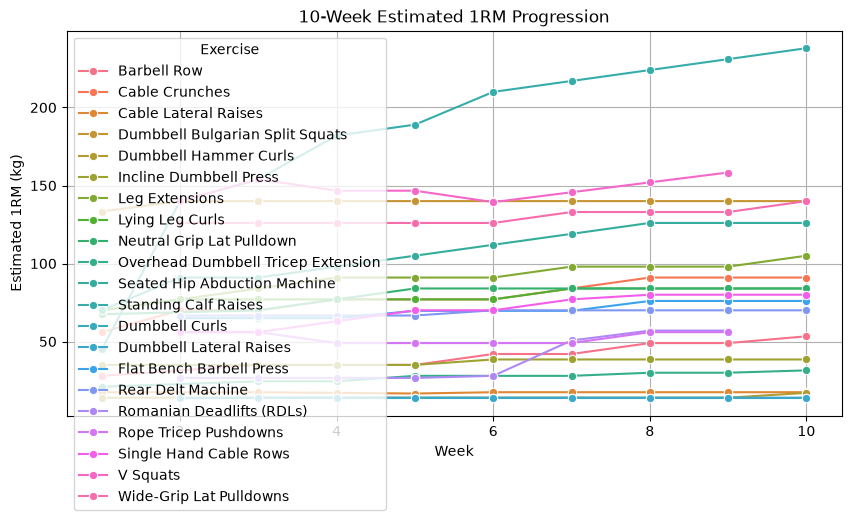

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate 1RM per set
df_long["e1RM"] = df_long["Clean_Weight"] * (1 + df_long["Reps"] / 30)

# Peak 1RM per exercise per week
weekly_1rm = df_long.groupby(["Week", "Exercise"])["e1RM"].max().reset_index()

# Plot progression for top compounds
plt.figure(figsize=(10, 5))
sns.lineplot(data=weekly_1rm, x="Week", y="e1RM", hue="Exercise", marker="o")
plt.title("10-Week Estimated 1RM Progression")
plt.ylabel("Estimated 1RM (kg)")
plt.grid(True)
plt.show()

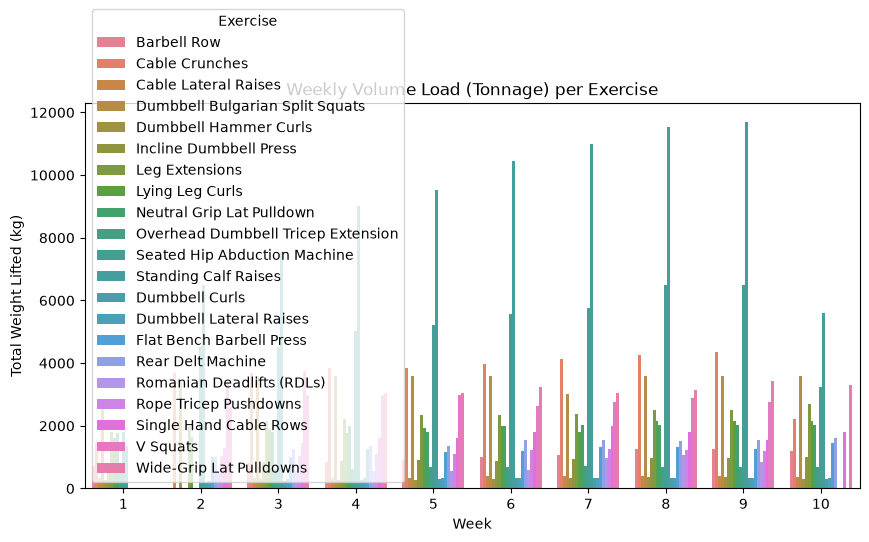

In [43]:
# Calculate Volume per set
df_long["Set_Volume"] = df_long["Clean_Weight"] * df_long["Reps"]

# Weekly total volume per exercise
weekly_vol = df_long.groupby(["Week", "Exercise"])["Set_Volume"].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=weekly_vol, x="Week", y="Set_Volume", hue="Exercise")
plt.title("Weekly Volume Load (Tonnage) per Exercise")
plt.ylabel("Total Weight Lifted (kg)")
plt.show()

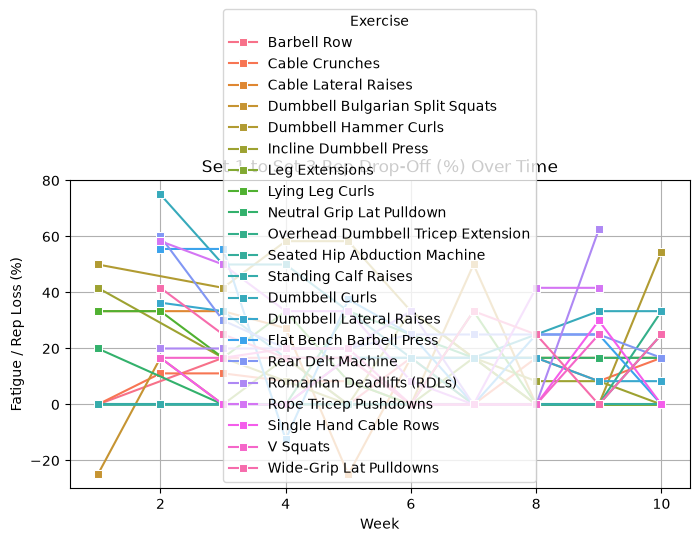

In [47]:
# Use pivot_table and define an aggregation function (mean, max, sum, etc.)
pivot_sets = df_long.pivot_table(
    index=["Week", "Exercise"],
    columns="Set",
    values="Reps",
    aggfunc="mean"  # or 'max', 'first'
).reset_index()

if 1 in pivot_sets.columns and 3 in pivot_sets.columns:
    pivot_sets["Dropoff_%"] = ((pivot_sets[1] - pivot_sets[3]) / pivot_sets[1]) * 100

    plt.figure(figsize=(8, 4))
    sns.lineplot(data=pivot_sets, x="Week", y="Dropoff_%", hue="Exercise", marker="s")
    plt.title("Set 1 to Set 3 Rep Drop-Off (%) Over Time")
    plt.ylabel("Fatigue / Rep Loss (%)")
    plt.grid(True)
    plt.show()

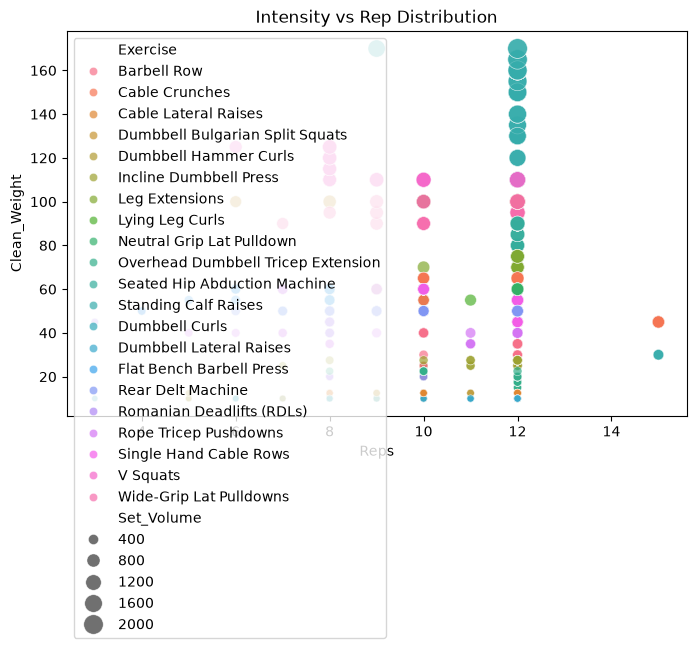

In [49]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df_long,
    x="Reps",
    y="Clean_Weight",
    hue="Exercise",
    size="Set_Volume",
    sizes=(20, 200),
    alpha=0.7
)
plt.title("Intensity vs Rep Distribution")
plt.show()